[Font] 已检测到中文字体: SimHei


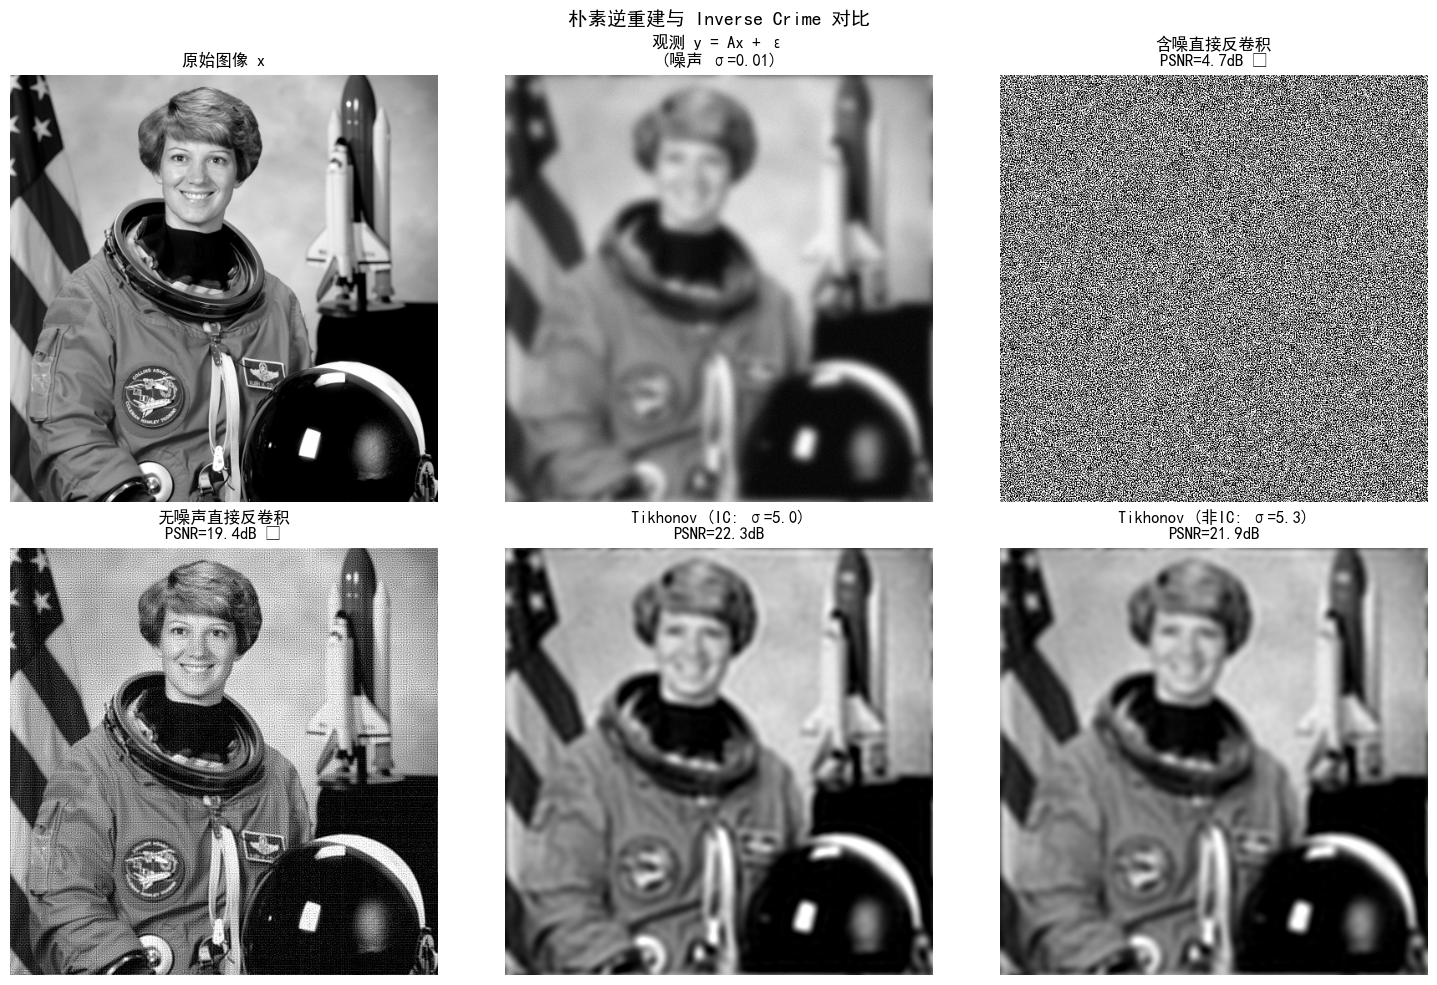

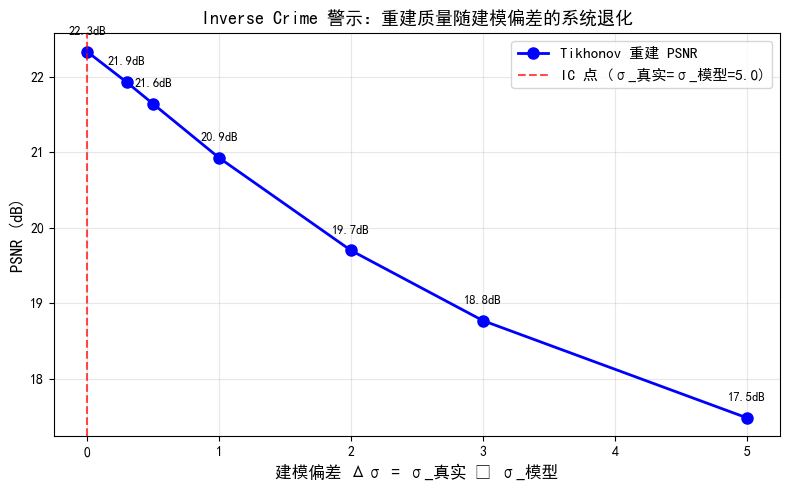


=== Inverse Crime 警示 ===
同模型(σ=5.0)生成 + 重建 → PSNR=22.3dB
异模型(σ=5.3)生成 + 重建 → PSNR=21.9dB
PSNR 差异: 0.41 dB

--- PSNR 随建模偏差变化 ---
  σ_真实=5.0 (偏差 Δσ=0.0) → PSNR=22.34 dB ← IC
  σ_真实=5.3 (偏差 Δσ=0.3) → PSNR=21.93 dB
  σ_真实=5.5 (偏差 Δσ=0.5) → PSNR=21.64 dB
  σ_真实=6.0 (偏差 Δσ=1.0) → PSNR=20.93 dB
  σ_真实=7.0 (偏差 Δσ=2.0) → PSNR=19.70 dB
  σ_真实=8.0 (偏差 Δσ=3.0) → PSNR=18.77 dB
  σ_真实=10.0 (偏差 Δσ=5.0) → PSNR=17.48 dB

建模偏差越大，重建质量系统性地越低——IC 条件下测得的性能不可靠！


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import astronaut
from skimage.color import rgb2gray
from skimage.transform import resize
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码（Windows + Linux 自动适配）======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['axes.unicode_minus'] = False

import platform
from matplotlib.font_manager import FontManager, FontProperties

def _find_chinese_font():
    """自动检测系统中可用的中文字体，兼容 Windows / Linux"""
    candidates = []
    if platform.system() == 'Windows':
        candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
    else:
        candidates = [
            'WenQuanYi Micro Hei', 'WenQuanYi Zen Hei',
            'Noto Sans CJK SC', 'Noto Sans CJK',
            'Source Han Sans SC', 'AR PL UMing CN',
            'SimHei',
        ]
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in candidates:
        if font in available:
            return font
    import os, re
    cjk_patterns = ['cjk', 'wqy', 'noto.*cjk', 'wenquan', 'chinese', 'simhei']
    for f in fm.ttflist:
        name_lower = f.name.lower()
        fname_lower = (os.path.basename(f.fname) if hasattr(f, 'fname') else '').lower()
        for pat in cjk_patterns:
            if re.search(pat, name_lower) or re.search(pat, fname_lower):
                return f.name
    return None

_cn_font = _find_chinese_font()
if _cn_font:
    plt.rcParams['font.sans-serif'] = [_cn_font] + plt.rcParams.get('font.sans-serif', [])
    plt.rcParams['font.family'] = 'sans-serif'
    print(f"[Font] 已检测到中文字体: {_cn_font}")
else:
    print("[Font] 未找到中文字体，中文可能显示为方框")
# ========================================================

np.random.seed(42)

# ---- 1. 准备图像和模糊算子 ----
x_color = astronaut()
x = rgb2gray(x_color)
n = x.shape[0]

def gaussian_psf(size, sigma):
    ax = np.concatenate((np.arange(0, size // 2), np.arange(-size // 2, 0)))
    xx, yy = np.meshgrid(ax, ax)
    h = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    return h / h.sum()

def blur(x, h):
    return np.real(np.fft.ifft2(np.fft.fft2(h) * np.fft.fft2(x)))

# 两个不同的 PSF：用于 Inverse Crime 对比
sigma_A = 5.0   # 重建模型使用的 PSF 宽度
sigma_B = 5.3   # 数据生成时使用的 PSF 宽度（微有差异，模拟建模误差）

h_A = gaussian_psf(n, sigma_A)  # 重建模型
h_B = gaussian_psf(n, sigma_B)  # "真实"模型

# ---- 2. 生成观测数据 ----
noise_sigma = 0.01  # 噪声水平

# 固定噪声实现，确保 IC/非IC 对比仅受模型差异影响
noise = noise_sigma * np.random.randn(n, n)

# (a) Inverse Crime 数据：用 h_A 生成
y_IC = blur(x, h_A) + noise

# (b) 非 Inverse Crime 数据：用 h_B 生成（使用相同噪声）
y_noIC = blur(x, h_B) + noise

# ---- 3. 朴素逆重建（频域直接除法）----
H_A = np.fft.fft2(h_A)

def naive_deconv(y, H, eps=1e-15):
    """频域直接反卷积：x = F^{-1}(F(y)/H)"""
    return np.real(np.fft.ifft2(np.fft.fft2(y) / (H + eps)))

# ---- 4. Tikhonov 正则化反卷积 ----
def tikhonov_deconv(y, H, lam):
    """Tikhonov 正则化反卷积：x = F^{-1}(H*/(|H|^2+λ) * F(y))"""
    H_star = np.conj(H)
    H_sq = np.abs(H) ** 2
    return np.real(np.fft.ifft2(H_star / (H_sq + lam) * np.fft.fft2(y)))

# ---- 5. 计算重建结果 ----
from skimage.metrics import peak_signal_noise_ratio

# 无噪声直接反卷积（理想情况）
y_clean = blur(x, h_A)
x_naive_clean = naive_deconv(y_clean, H_A)

# 含噪直接反卷积
x_naive_noisy = naive_deconv(y_IC, H_A)

# Inverse Crime：同模型生成+重建
x_tikh_IC = tikhonov_deconv(y_IC, H_A, lam=1e-2)

# 非 Inverse Crime：异模型生成+重建
x_tikh_noIC = tikhonov_deconv(y_noIC, H_A, lam=1e-2)

# ---- 6. PSNR vs 建模偏差曲线 ----
sigma_B_list = [5.0, 5.3, 5.5, 6.0, 7.0, 8.0, 10.0]
psnr_curve = []
for sb in sigma_B_list:
    h_tmp = gaussian_psf(n, sb)
    y_tmp = blur(x, h_tmp) + noise
    x_tmp = tikhonov_deconv(y_tmp, H_A, lam=1e-2)
    psnr_curve.append(peak_signal_noise_ratio(x, np.clip(x_tmp, 0, 1)))

# ---- 7. 可视化：图像对比 ----
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 上排：逆问题与不适定性
axes[0, 0].imshow(x, cmap='gray')
axes[0, 0].set_title('原始图像 x')
axes[0, 0].axis('off')

axes[0, 1].imshow(y_IC, cmap='gray')
axes[0, 1].set_title('观测 y = Ax + ε\n(噪声 σ=0.01)')
axes[0, 1].axis('off')

psnr_naive = peak_signal_noise_ratio(x, np.clip(x_naive_noisy, 0, 1))
axes[0, 2].imshow(np.clip(x_naive_noisy, 0, 1), cmap='gray')
axes[0, 2].set_title(f'含噪直接反卷积\nPSNR={psnr_naive:.1f}dB ✗')
axes[0, 2].axis('off')

# 下排：正则化与 Inverse Crime
psnr_clean = peak_signal_noise_ratio(x, np.clip(x_naive_clean, 0, 1))
psnr_tikh_IC = peak_signal_noise_ratio(x, np.clip(x_tikh_IC, 0, 1))
psnr_tikh_noIC = peak_signal_noise_ratio(x, np.clip(x_tikh_noIC, 0, 1))

axes[1, 0].imshow(np.clip(x_naive_clean, 0, 1), cmap='gray')
axes[1, 0].set_title(f'无噪声直接反卷积\nPSNR={psnr_clean:.1f}dB ✓')
axes[1, 0].axis('off')

axes[1, 1].imshow(np.clip(x_tikh_IC, 0, 1), cmap='gray')
axes[1, 1].set_title(f'Tikhonov (IC: σ={sigma_A})\nPSNR={psnr_tikh_IC:.1f}dB')
axes[1, 1].axis('off')

axes[1, 2].imshow(np.clip(x_tikh_noIC, 0, 1), cmap='gray')
axes[1, 2].set_title(f'Tikhonov (非IC: σ={sigma_B})\nPSNR={psnr_tikh_noIC:.1f}dB')
axes[1, 2].axis('off')

plt.suptitle('朴素逆重建与 Inverse Crime 对比', fontsize=14)
plt.tight_layout()
plt.savefig('实验1_5_不适定性与InverseCrime.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 8. 可视化：PSNR vs 建模偏差曲线 ----
fig2, ax2 = plt.subplots(figsize=(8, 5))
deviations = [sb - sigma_A for sb in sigma_B_list]
ax2.plot(deviations, psnr_curve, 'bo-', markersize=8, linewidth=2, label='Tikhonov 重建 PSNR')
ax2.axvline(x=0, color='r', linestyle='--', alpha=0.7, label=f'IC 点 (σ_真实=σ_模型={sigma_A})')
ax2.set_xlabel('建模偏差 Δσ = σ_真实 − σ_模型', fontsize=12)
ax2.set_ylabel('PSNR (dB)', fontsize=12)
ax2.set_title('Inverse Crime 警示：重建质量随建模偏差的系统退化', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# 标注每个数据点的 PSNR 值
for d, p in zip(deviations, psnr_curve):
    ax2.annotate(f'{p:.1f}dB', (d, p), textcoords="offset points",
                 xytext=(0, 12), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('实验1_5_PSNR_vs_建模偏差.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 9. 打印结果 ----
print("\n=== Inverse Crime 警示 ===")
print(f"同模型(σ={sigma_A})生成 + 重建 → PSNR={psnr_tikh_IC:.1f}dB")
print(f"异模型(σ={sigma_B})生成 + 重建 → PSNR={psnr_tikh_noIC:.1f}dB")
print(f"PSNR 差异: {psnr_tikh_IC - psnr_tikh_noIC:.2f} dB")
print(f"\n--- PSNR 随建模偏差变化 ---")
for sb, p in zip(sigma_B_list, psnr_curve):
    marker = " ← IC" if sb == sigma_A else ""
    print(f"  σ_真实={sb:.1f} (偏差 Δσ={sb-sigma_A:.1f}) → PSNR={p:.2f} dB{marker}")
print("\n建模偏差越大，重建质量系统性地越低——IC 条件下测得的性能不可靠！")
